# **Coffee sales**

### Tools & Technologies Used

- Python – Core programming language used for data analysis and modeling  
- Pandas – Data cleaning, manipulation, and preprocessing  
- NumPy – Numerical computations and array operations  
- Matplotlib – Data visualization and plotting  
- Seaborn – Advanced statistical data visualization  
- Scikit-learn – Machine learning library used for:
  - Linear Regression (baseline model)
  - Random Forest Regressor (final model)
  - Train-test split and model evaluation

### Problem Statement

The coffee shop generates large volumes of sales data, but lacks clear insights into customer behavior, product performance, and revenue trends. Without proper analysis, it becomes difficult to make informed business decisions. This project analyzes sales data to uncover patterns and support data-driven decision-making to improve profitability.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")

## **Load Dataset**
The dataset includes coffee sales data such as coffee type, payment method, date, time, and revenue. It is used to analyze sales trends and predict future sales performance.

In [3]:
df = pd.read_csv("/content/index.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


,money
count,1133.000000
mean,33.105808
std,5.035366
min,18.120000
25%,28.900000
50%,32.820000
75%,37.720000
max,40.000000


In [4]:
# Convert date columns
df['date'] = pd.to_datetime(df['date'])
df['datetime'] = pd.to_datetime(df['datetime'])

# Handle missing card values
df['card'] = df['card'].fillna("Cash_User")

# Create new time features
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.dayofweek
df['hour'] = df['datetime'].dt.hour

## Data Cleaning & Preprocessing
- Converted date columns to datetime format  
- Handled missing values in `card` column  
- Ensured correct data types  

## Feature Engineering
- Extracted month, day, and hour from date/time  
- Encoded categorical variables for modeling  

## Handling Missing Values
- Identified missing values using `.isnull()`  
- Filled missing `card` values with "Cash_User"  

## Statistical Analysis
- Used `.describe()` for summary statistics  
- Observed average sales ≈ 33.10  

## Final Dataset
- Final dataset contains 1133 rows with additional engineered features  
- Ready for analysis and machine learning

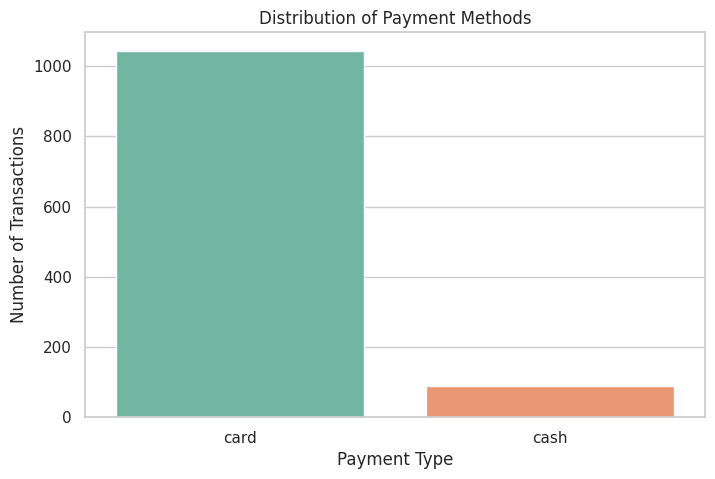

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='cash_type',
    hue='cash_type',   # add this
    data=df,
    palette="Set2",
    legend=False       # remove duplicate legend
)

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Type")
plt.ylabel("Number of Transactions")

plt.show()

## Distribution of Payment Methods

### What this chart shows
This chart displays the distribution of transactions based on different payment methods used for coffee purchases.

### Key observations
- One payment method is used significantly more than others  
- Cash-based transactions appear frequently (including Cash_User entries)  
- Digital/card payments are also widely used but slightly lower in count  

### Business insight
The dominance of a particular payment method indicates customer preference and convenience. Understanding payment behavior helps in optimizing payment options and improving customer experience.

### Actionable recommendation
- Ensure smooth functioning of the most preferred payment method  
- Promote digital payments through offers or discounts  
- Monitor payment trends to adapt to changing customer preferences  

### Key takeaway
Customer payment preferences play an important role in transaction behavior, and optimizing popular payment methods can enhance overall sales and user satisfaction.

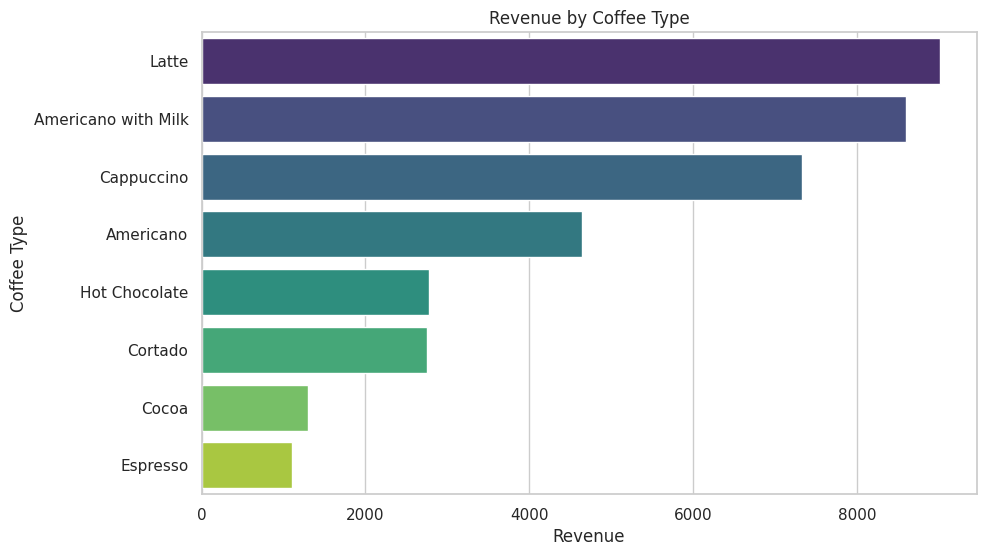

In [8]:
# Create revenue variable first
revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x=revenue.values,
    y=revenue.index,
    hue=revenue.index,
    palette="viridis",
    legend=False
)

plt.title("Revenue by Coffee Type")
plt.xlabel("Revenue")
plt.ylabel("Coffee Type")

plt.show()

## Revenue by Coffee Type

### What this chart shows
This chart displays the total revenue generated by each type of coffee, helping identify the best-performing products.

### Key observations
- Certain coffee types generate significantly higher revenue than others  
- A few top-performing items contribute the majority of total sales  
- Some coffee types have relatively low revenue, indicating lower demand  

### Business insight
The variation in revenue across coffee types highlights customer preferences. High-revenue items are likely more popular and should be prioritized in marketing and inventory planning.

### Actionable recommendation
- Focus on promoting top-selling coffee types to maximize revenue  
- Analyze low-performing items and consider improving or replacing them  
- Optimize pricing and offers based on popular products  

### Key takeaway
A small number of coffee types drive most of the revenue, making them critical for business growth and sales strategy.

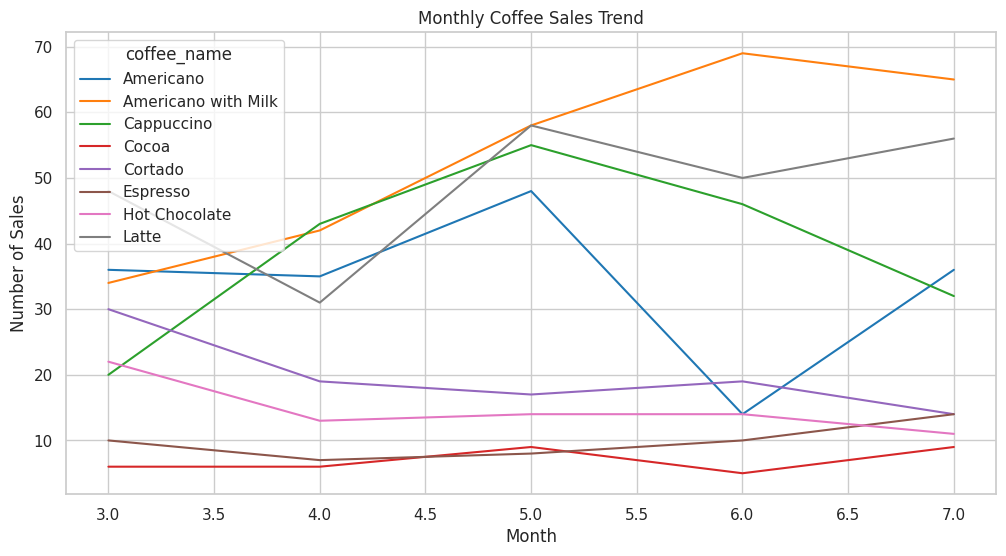

In [9]:
monthly_sales = df.groupby(['month','coffee_name']).size().reset_index(name='count')

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='count',
    hue='coffee_name',
    palette="tab10"
)

plt.title("Monthly Coffee Sales Trend")
plt.xlabel("Month")
plt.ylabel("Number of Sales")

plt.show()

## Monthly Coffee Sales Trend

### What this chart shows
This chart displays the monthly sales trend for different coffee types, showing how demand varies over time.

### Key observations
- Sales patterns vary across different months  
- Some coffee types show consistent demand, while others fluctuate  
- Certain months may have higher overall sales, indicating seasonal trends  

### Business insight
Monthly trends help identify peak sales periods and customer preferences over time. Understanding these patterns allows better planning for inventory, promotions, and staffing.

### Actionable recommendation
- Increase stock and marketing efforts during high-demand months  
- Analyze low-sales periods and introduce offers to boost sales  
- Focus on consistently performing coffee types for stable revenue  

### Key takeaway
Coffee sales vary over time, and identifying seasonal trends is essential for optimizing business strategy and maximizing revenue.

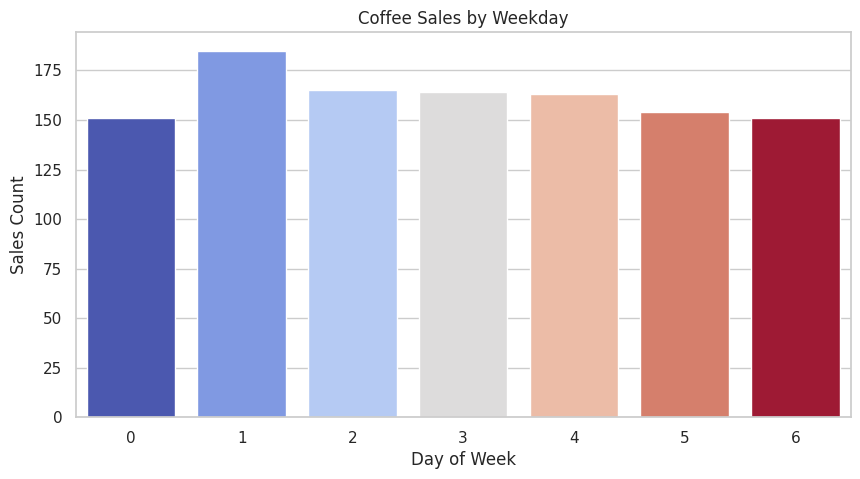

In [10]:
weekday_sales = df.groupby('day').size()

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values,
    hue=weekday_sales.index,
    palette="coolwarm",
    legend=False
)

plt.title("Coffee Sales by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Sales Count")

plt.show()

## Coffee Sales by Weekday

### What this chart shows
This chart displays the number of coffee sales across different days of the week, helping identify which days have higher or lower customer activity.

### Key observations
- Sales vary across different weekdays  
- Certain days show higher transaction counts, indicating peak demand  
- Some days have relatively lower sales, suggesting reduced customer activity  

### Business insight
Weekday sales patterns highlight customer behavior and peak business days. Understanding these trends helps in optimizing operations, staffing, and inventory management.

### Actionable recommendation
- Increase staffing and stock on high-sales days to meet demand  
- Introduce promotions or discounts on low-sales days to boost traffic  
- Align business strategies based on customer activity patterns  

### Key takeaway
Sales performance differs across weekdays, and identifying peak days is essential for improving efficiency and maximizing revenue.

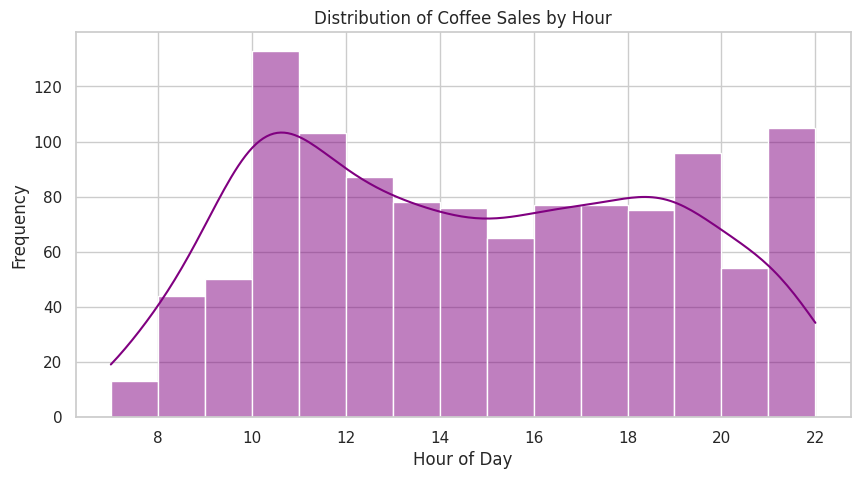

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['hour'],
    bins=15,
    kde=True,
    color="purple"
)

plt.title("Distribution of Coffee Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")

plt.show()

## Distribution of Coffee Sales by Hour

### What this chart shows
This chart displays the distribution of coffee sales across different hours of the day, highlighting peak and low activity periods.

### Key observations
- Sales are concentrated during specific hours of the day  
- There are clear peak hours where transaction frequency is highest  
- Sales drop significantly during late or off-peak hours  

### Business insight
Hourly sales patterns help identify peak business hours and customer purchasing behavior. This information is crucial for optimizing staffing, inventory, and service efficiency.

### Actionable recommendation
- Increase staff availability during peak hours to handle higher demand  
- Schedule maintenance or downtime during low-activity hours  
- Introduce time-based offers to boost sales during off-peak periods  

### Key takeaway
Coffee sales are time-dependent, and understanding hourly trends is essential for improving operational efficiency and maximizing revenue.

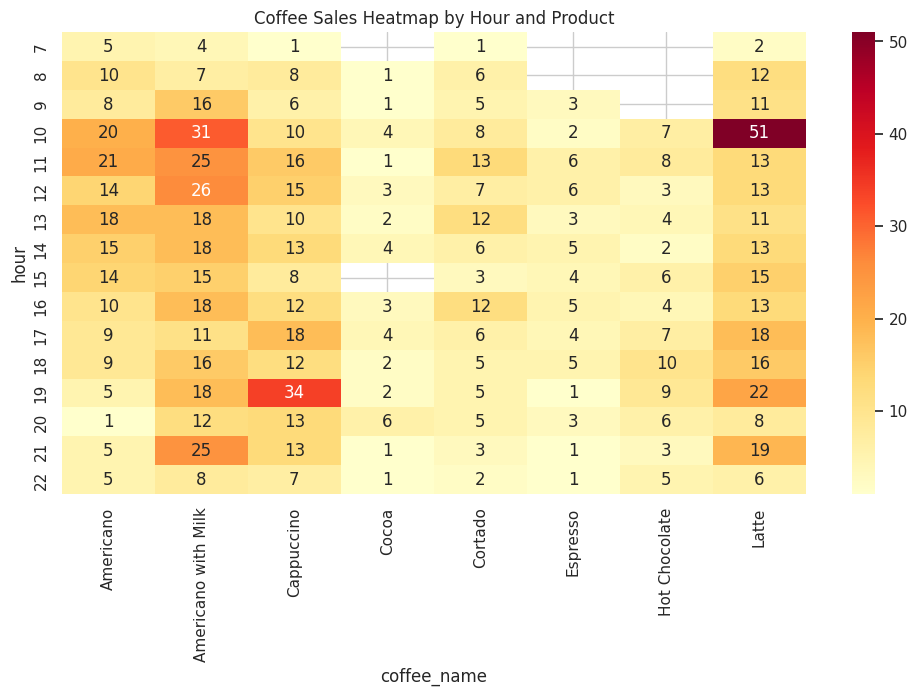

In [ ]:
heatmap_data = df.pivot_table(
    values='money',
    index='hour',
    columns='coffee_name',
    aggfunc='count'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Coffee Sales Heatmap by Hour and Product")

plt.show()

## Coffee Sales Heatmap by Hour and Product

### What this chart shows
This heatmap visualizes the number of coffee sales across different hours of the day for each coffee type, highlighting patterns in demand.

### Key observations
- Certain coffee types have higher sales during specific hours  
- Peak hours show intense activity across multiple products  
- Some coffee types have consistently low or limited demand throughout the day  

### Business insight
The heatmap helps identify which products are popular at specific times, enabling better alignment of supply with customer demand. It also reveals time-based preferences for different coffee types.

### Actionable recommendation
- Stock and promote specific coffee types during their peak hours  
- Adjust menu visibility based on time-of-day preferences  
- Optimize staffing and preparation for high-demand combinations  

### Key takeaway
Sales patterns vary by both time and product, and understanding these interactions is crucial for maximizing efficiency and revenue.

# **Machine Learning Model**

In [11]:
le = LabelEncoder()

df_ml = df.copy()

df_ml['coffee_name'] = le.fit_transform(df_ml['coffee_name'])
df_ml['cash_type'] = le.fit_transform(df_ml['cash_type'])

In [12]:
X = df_ml[['coffee_name','cash_type','month','day','hour']]
y = df_ml['money']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

In [15]:
mse = mean_squared_error(y_test,pred)
r2 = r2_score(y_test,pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 15.649966239146611
R2 Score: 0.15934845267098618


In [16]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict sales
rf_pred = rf_model.predict(X_test)

# Evaluate performance
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MSE: 0.5704567090860373
Random Forest R2 Score: 0.9693574217446015


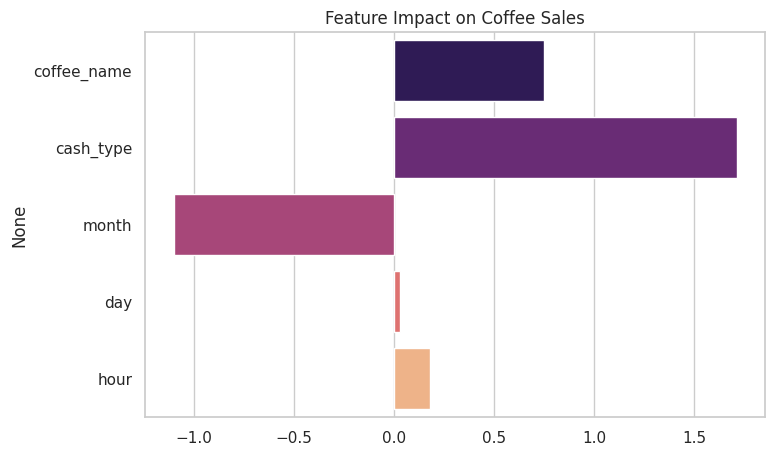

In [18]:
importance = model.coef_

plt.figure(figsize=(8,5))

sns.barplot(
    x=importance,
    y=X.columns,
    hue=X.columns,
    palette="magma",
    legend=False
)

plt.title("Feature Impact on Coffee Sales")

plt.show()

The above graph is used to show the impact of various features on the prediction of coffee sales using the machine learning model. From the above chart, it is clear that the payment type, denoted by ‘cash_type,’ has the maximum impact on the prediction of coffee sales, followed by the coffee product type. It is also evident that the time-related factors, such as ‘hour’ and ‘day,’ have less impact, whereas the ‘month’ factor has a slight negative impact.

## Conclusion

This analysis was conducted on coffee vending machine sales data to understand customer behavior, product popularity, and sales trends over time.

The exploratory data analysis revealed that most customers prefer card payments over cash, indicating a shift toward digital payment methods. Revenue analysis showed that Latte, Americano with Milk, and Cappuccino generate the highest sales, highlighting the popularity of milk-based coffee among customers.

Sales were found to be relatively consistent throughout the week, with slight variations on certain days. Time-based analysis indicated that coffee sales are higher during morning and evening hours, which aligns with typical work and break schedules.

The heatmap analysis provided deeper insights into product demand across different hours. For example, Latte and Americano with Milk are more popular in the morning, while Cappuccino and Hot Chocolate show higher demand in the evening.

Machine learning models were used to predict coffee sales based on features such as coffee type, payment method, and time variables. The Linear Regression model resulted in a Mean Squared Error (MSE) of approximately 15.65 and an R² score of around 0.16, indicating limited predictive performance. This suggests that additional factors influencing coffee sales may not be captured in the dataset.

Feature importance analysis showed that payment method and coffee type have the most significant impact on sales prediction, while time-related features like day and hour have comparatively less influence.

Overall, the analysis successfully identified key trends and factors influencing coffee sales, providing valuable insights for improving business strategies and decision-making.